<a href="https://colab.research.google.com/github/Subroy1/MSAI_AllPracticeModules/blob/main/Module%2013/Assignment_13_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Required Assignment 13.1: Introduction to Logistic Regression with Scikit-Learn

**Expected Time = 60 minutes**

**Total Points = 60**

This activity introduces the `LogisticRegression` estimator from scikit-learn.  After fitting the model on a single feature for binary classes, you will plot the sigmoid curve to represent the learned model in terms of probabilities.  Finally, you will evaluate the model in terms of accuracy, precision, and recall.  

#### Index

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)
- [Problem 3](#-Problem-3)
- [Problem 4](#-Problem-4)
- [Problem 5](#-Problem-5)
- [Problem 6](#-Problem-6)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.model_selection import train_test_split

from scipy.optimize import minimize

In [2]:
penguins = sns.load_dataset('penguins').dropna()
penguins = penguins.loc[(penguins['species'] == 'Adelie') | (penguins['species'] == 'Gentoo')]
X = penguins.drop('species', axis = 1)[['flipper_length_mm']]
y = np.where(penguins.species == 'Adelie', 0, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)
X.head(2)

,flipper_length_mm
0,181.0
1,186.0


In [3]:
X = penguins[['flipper_length_mm']]
X.head(2)

,flipper_length_mm
0,181.0
1,186.0


Text(0.5, 1.0, 'Flipper length by species')

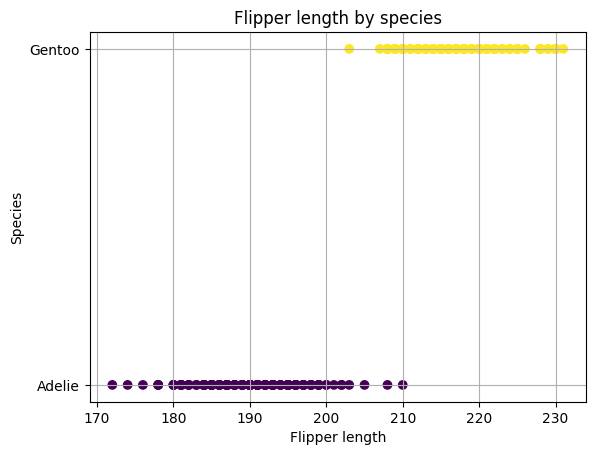

In [ ]:
plt.scatter (X, penguins['species'], c = y )
plt.grid()
plt.xlabel("Flipper length")
plt.ylabel("Species")
plt.title("Flipper length by species")

[Back to top](#-Index)

### Problem 1

#### Building a Logistic Model

**10 Points**


Instantiate and fit a `LogisticRegression` estimato the the `log_reg` variable on the training data `X_train` and `y_train`.


In [4]:
### GRADED
logreg = ''
# YOUR CODE HERE
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# Answer check
print(logreg)

LogisticRegression()


In [ ]:
X_train

,flipper_length_mm
92,185.0
340,215.0
43,196.0
220,211.0
253,230.0
...,...
25,187.0
263,216.0
77,184.0
112,193.0


-165.4346533232972
----
[[0.80214402]]


In [ ]:
np.round(predictions.head())

,flipper_length_mm
92,-17.0
340,7.0
43,-8.0
220,4.0
253,19.0


[Back to top](#-Index)

### Problem 2

#### Examining the coefficients

**10 Points**

Similar to the `LinearRegression` estimator, your `log_reg` estimator now has a `.coef_` and `.intercept_` attribute.  Your goal is to calculate a linear combination of the input with these coefficients and intercept terms.

Below, complete the function `linear_predictions` that takes in a fit regression model `model`, and a feature array `X`.  This function should return the predictions according to the formula: $$ \text{intercept} + \text{coef}*X$$

In [6]:
### GRADED
def linear_predictions(model, X):
    """
    This function takes in a fit linear model
    and returns the models intercept + coefs*X (this is same as beta0+ beta1*x)

    Arguments
    ---------
    model: scikitlearn.linear_model
           Linear Model estimator -- Linear or Logistic Regression
           that is already fit
    X: pd.DataFrame (N,1)
        1 Feature DataFrame with 1 feature

    Returns
    --------
    odds: pd.DataFrame
         Array of odds based on input X
    """
    intercept = model.intercept_[0]
    coeff= model.coef_[0,0]
    preds = intercept+ (coeff*X)
    print (-intercept/coeff)
    return preds

# YOUR CODE HERE

# Answer check

predictions = linear_predictions(logreg, X_train)
np.round(predictions.head())


206.24058781737773


,flipper_length_mm
92,-17.0
340,7.0
43,-8.0
220,4.0
253,19.0


[Back to top](#-Index)

### Problem 3

#### Examining the log odds

**10 Points**

The predictions above are the logarithmic odds for the positive class.  In order to interpret these as probabilities, you need to return to the original sigmoid form using the formula:

$$\sigma(x) = \frac{1}{1 + e^{-(ax + b)}}$$

Complete the function `sigma` below that takes as input the array  `predictions`. This function should return the values of the sigmoid function evaluated at `predictions`.  The results should look like the image below when plotted.

<center>
    <img src = 'images/sigmoid.png' />
</center>

[[3.98552997e-08]
 [9.99112585e-01]
 [2.70646527e-04]
 [9.78495080e-01]
 [9.99999995e-01]
 [9.99999350e-01]
 [9.53273482e-01]
 [2.19947353e-06]
 [2.99445470e-03]
 [2.70646527e-04]
 [9.53273482e-01]
 [1.78697867e-08]
 [9.99992784e-01]
 [1.21366990e-04]
 [1.45184101e-10]
 [9.99983906e-01]
 [9.99112585e-01]
 [9.99999995e-01]
 [1.21366990e-04]
 [1.21366990e-04]
 [1.98252855e-07]
 [9.99999995e-01]
 [9.99821474e-01]
 [4.42166732e-07]
 [9.98022941e-01]
 [9.99999708e-01]
 [8.03971215e-01]
 [9.86171727e-07]
 [2.19947353e-06]
 [1.21366990e-04]
 [9.99983906e-01]
 [9.95601231e-01]
 [4.90551135e-06]
 [9.01450482e-01]
 [1.61071691e-09]
 [3.98552997e-08]
 [2.44010917e-05]
 [9.99996764e-01]
 [2.19947353e-06]
 [2.19947353e-06]
 [9.99964105e-01]
 [2.69899980e-01]
 [9.99919947e-01]
 [9.53273482e-01]
 [2.19947353e-06]
 [6.03426793e-04]
 [3.59241033e-09]
 [1.78697867e-08]
 [2.19947353e-06]
 [3.98552997e-08]
 [4.90551135e-06]
 [2.44010917e-05]
 [1.98252855e-07]
 [9.99112585e-01]
 [1.09407825e-05]
 [8.039712

Text(0.5, 1.0, 'Probability of x from sigma (x)')

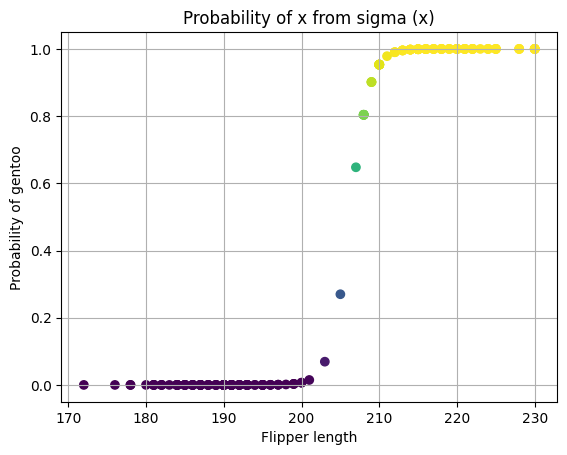

In [8]:
### GRADED

def sigma(predictions):
    """
    This function takes in predictions as log odds and
    returns their probability of being the positive class
    in a binary classification setting.

    Arguments
    ---------
    predictions; np.array
            array of log odds prediction values for each data
            point  which is same as log (p/1-p) ,p being the positive class = beta0+ beta1*x = intercept+ coef*x .
    Returns
    ---------
    probabilities: np.array
            array of probabilities for positive class
    """
    return np.array(1 / (1+ np.exp(-predictions)))

# YOUR CODE HERE

# Answer check
probs = sigma(predictions)
print(probs)
# Plot the probabilites
plt.scatter (X_train, probs, c = probs)
plt.grid()
plt.xlabel("Flipper length")
plt.ylabel("Probability of gentoo")
plt.title("Probability of x from sigma (x)")


[Back to top](#-Index)

### Problem 4

#### Making Class Predictions

**10 Points**

In this exercise you will use the probabilities obtained from the sigmoid function to make predictions.  

Specifically, if a probability is greater than or equal to 0.5, assign this to the positive class `1`, otherwise assign it to the class `0`.  Assign your solution as a numpy array to `class_predictions` below.

In [ ]:
### GRADED
class_predictions = ''
# YOUR CODE HERE


# Answer check
print(np.unique(class_predictions, return_counts=True)[1])

[Back to top](#-Index)

### Problem 5

#### Using the `predict_proba` method

**10 Points**

You don't need to go through this process each time you fit a Logistic model to determine these probabilities.

The `LogisticRegression` estimator has a `.predict_proba` method to calculate the predictions that returns the probabilities for each class as a 2D NumPy array.

Below, use the `.predict_proba` method of the `logreg` object on the test data `X_test` as a 1D NumPy array. Assign the result to `positive_probs`.



In [ ]:
### GRADED
positive_probs = ''
# YOUR CODE HERE


# Answer check
print(positive_probs.shape) #(67,)
#plt.scatter(X_test, positive_probs, c = y_test)

[Back to top](#-Index)

### Problem 6

#### Scoring the Classifier

**10 Points**

You may be interested in different metrics for your classifier.  

Below, use the `predict` function of the `logreg` method with arugmemnt equal to `X_test` to calculate your predictions. Assign the result to `preds`.

Then, use the functions `accuracy_score`, `precision_score`, and `recall_score`to calcutate the accuracy, precision, and recall for your model. Assing the results to `accuracy`, `precision`, and `recall`, respectively.


In [ ]:
### GRADED
preds = ''
accuracy = ''
precision = ''
recall = ''
# YOUR CODE HERE


# Answer check
print(f'Accuracy: {accuracy: .2f}\nPrecision: {precision: .2f}\nRecall: {recall: .2f}')

From this example it seems you have a powerful classifier.  In the following activity, you will explore more about exactly where these coefficients come from and how they are determined in general.  